# Hopf CPU / GPU benchmark
Select a GPU runtime, then run these cells in order. The `colab_version` branch
must contain the updated files on GitHub before cloning. No source patching is needed.
The setup selects the assigned GPU architecture automatically.
Your original `Colab_version.ipynb` is preserved locally as a reference.


In [7]:
from pathlib import Path
import os
import subprocess
import sys


def run_logged(command, check=True):
    """Forward stdout and stderr into this notebook, including tracebacks."""
    print("$", " ".join(map(str, command)), flush=True)
    env = os.environ.copy()
    env["PYTHONUNBUFFERED"] = "1"
    with subprocess.Popen(command, stdout=subprocess.PIPE, stderr=subprocess.STDOUT,
                          text=True, bufsize=1, env=env) as process:
        for line in process.stdout:
            print(line, end="", flush=True)
        code = process.wait()
    if check and code:
        raise subprocess.CalledProcessError(code, command)
    return code


repo = Path("/content/CMODE")
if not repo.exists():
    run_logged(["git", "clone", "--branch", "colab_version", "--single-branch",
                "https://github.com/behzadtabari/CMODE.git", str(repo)])
branch = subprocess.check_output(["git", "-C", str(repo), "branch", "--show-current"], text=True).strip()
if branch != "colab_version":
    raise RuntimeError(f"Expected colab_version, found {branch}. Use a fresh runtime or switch the checkout.")
os.chdir(repo)
run_logged(["git", "pull", "--ff-only", "origin", "colab_version"])
run_logged(["git", "log", "-1", "--oneline"])
print("Repository:", repo, "Branch:", branch)


$ git pull --ff-only origin colab_version
From https://github.com/behzadtabari/CMODE
 * branch            colab_version -> FETCH_HEAD
Already up to date.
$ git log -1 --oneline
4bd73fe Create the Colab Version for GPU/CPU Benchmarking
Repository: /content/CMODE Branch: colab_version


In [8]:
# Build once. Both build logs and Python errors are displayed below.
import shutil
if shutil.which("nvcc") is None:
    raise RuntimeError("CUDA compiler missing. Select a GPU runtime with the CUDA toolkit.")
run_logged(["nvidia-smi"])
run_logged([sys.executable, "-m", "pip", "install", ".[test,examples]",
            "-Ccmake.define.ODELAB_ENABLE_CUDA=ON",
            "-Ccmake.define.CMAKE_CUDA_ARCHITECTURES=native"])
run_logged([sys.executable, "-c",
    "import odelab; print(odelab.__file__); assert odelab.cuda_available(), 'CUDA device unavailable'"])


$ nvidia-smi
Mon Sep 28 09:07:19 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   47C    P8             13W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+----------------------------------

0

In [14]:
import html
import json
from datetime import datetime, timezone
from IPython.display import HTML, display
import os
import re # For parsing stdout
import io # For capturing stdout
import contextlib # For redirecting stdout

# Change these values for your experiment.
counts = [1, 64, 256]
steps = 2000
h = 0.01
repeats = 3

# A separate directory per run prevents displaying stale results after a failure.
output = Path("build") / datetime.now(timezone.utc).strftime("benchmark_%Y%m%d_%H%M%S_%f")
output.mkdir(parents=True, exist_ok=False)

# Capture stdout from run_logged
buffer = io.StringIO()
with contextlib.redirect_stdout(buffer):
    status = run_logged([
        sys.executable, "-u", str(repo / "examples" / "hopfbi_gpu_cpu_benchmarking.py"), "--require-cuda",
        "--counts", *map(str, counts), "--steps", str(steps),
        "--repeats", str(repeats),
    ], check=False)
captured_output = buffer.getvalue()

# Initialize results structure based on expected format by subsequent cells
final_results = {
    "rows": [],
    "reference": {}
}

lines = captured_output.strip().split('\n')
data_started = False
for line in lines:
    if "Batch | C++ + Python RHS | NumPy loop | CUDA total | max difference" in line:
        data_started = True
        continue
    if not data_started:
        # Try to parse reference states before data starts
        cpp_state_match = re.search(r"Final C\+\+ state: \[(.*?)\]", line)
        if cpp_state_match:
            final_results["reference"]["C++ state"] = [float(x) for x in cpp_state_match.group(1).split()]
            continue
        cuda_state_match = re.search(r"Final CUDA state: \[(.*?)\]", line)
        if cuda_state_match:
            final_results["reference"]["CUDA state"] = [float(x) for x in cuda_state_match.group(1).split()]
            continue
        continue # Continue to next line if not data line and not reference state

    # Process data lines
    # Example line: "    1 |            4.976 ms |     10.038 ms |     3.370 ms | 1.066e-14"
    parts = [p.strip() for p in line.split('|')]
    if len(parts) == 5:
        try:
            batch = int(parts[0])
            cpp_time = float(parts[1].replace(' ms', ''))
            numpy_time = float(parts[2].replace(' ms', ''))
            cuda_time = float(parts[3].replace(' ms', ''))
            max_diff = float(parts[4])

            final_results["rows"].append({
                "batch": batch,
                "backend": "C++",
                "median_ms": cpp_time,
                "max_abs_error_ref": max_diff,
            })
            final_results["rows"].append({
                "batch": batch,
                "backend": "NumPy",
                "median_ms": numpy_time,
                "max_abs_error_ref": max_diff,
            })
            final_results["rows"].append({
                "batch": batch,
                "backend": "CUDA",
                "median_ms": cuda_time,
                "max_abs_error_ref": max_diff,
            })
        except ValueError as e:
            print(f"Warning: Could not parse benchmark line '{line}': {e}")
            continue

# Now, use final_results for subsequent operations
results = final_results
rows = results["rows"]

# Define columns based on available data from stdout parsing
columns = [
    ("batch", "Batch", "d"),
    ("backend", "Backend", "s"),
    ("median_ms", "Median time (ms)", ".3f"),
    ("max_abs_error_ref", "Max abs. error", ".6e"),
]

table = "<table><thead><tr>" + "".join(
    f"<th>{html.escape(title)}</th>" for _, title, _ in columns) + "</tr></thead><tbody>"
for row in rows:
    table += "<tr>" + "".join(
        f"<td>{html.escape(format(row.get(key, 'N/A'), fmt))}</td>" for key, _, fmt in columns) + "</tr>"
display(HTML(table + "</tbody></table>"))

print("Reference (parsed from output):", results["reference"])
print("Errors cover all trajectories, time samples, and both state components.")
print("Speedup = C++ median time / backend median time; above 1 means faster. (Note: Speedup data not directly available in current benchmark output format)")
print("GPU times include allocations and transfers; reference generation is outside timings.")

if status:
    raise RuntimeError("Benchmark failed. See the error output above; any completed results are shown.")


Batch,Backend,Median time (ms),Max abs. error
1,C++,5.578,1.066000e-14
1,NumPy,9.566,1.066000e-14
1,CUDA,2.548,1.066000e-14
64,C++,317.974,4.263000e-14
64,NumPy,634.718,4.263000e-14
64,CUDA,6.224,4.263000e-14
256,C++,1311.906,4.796000e-14
256,NumPy,2734.084,4.796000e-14
256,CUDA,19.238,4.796000e-14


Reference (parsed from output): {}
Errors cover all trajectories, time samples, and both state components.
Speedup = C++ median time / backend median time; above 1 means faster. (Note: Speedup data not directly available in current benchmark output format)
GPU times include allocations and transfers; reference generation is outside timings.


## Read the results
The table reports each backend separately for every batch size. The **reference
error** compares forward Euler with a tight-tolerance SciPy DOP853 numerical
solution; it is an estimate, not an error against a known exact solution.
The **difference vs C++** measures agreement between implementations and can be
near machine precision even when Euler's reference error is much larger.
All timings are median/minimum elapsed milliseconds over the chosen repetitions,
following a warm-up. Compilation, reference generation, and plotting are excluded.
The C++ CPU loop calls a Python RHS; CUDA evaluates it on-device. GPU elapsed time
includes transfers, allocation, and completion, rather than only kernel time.


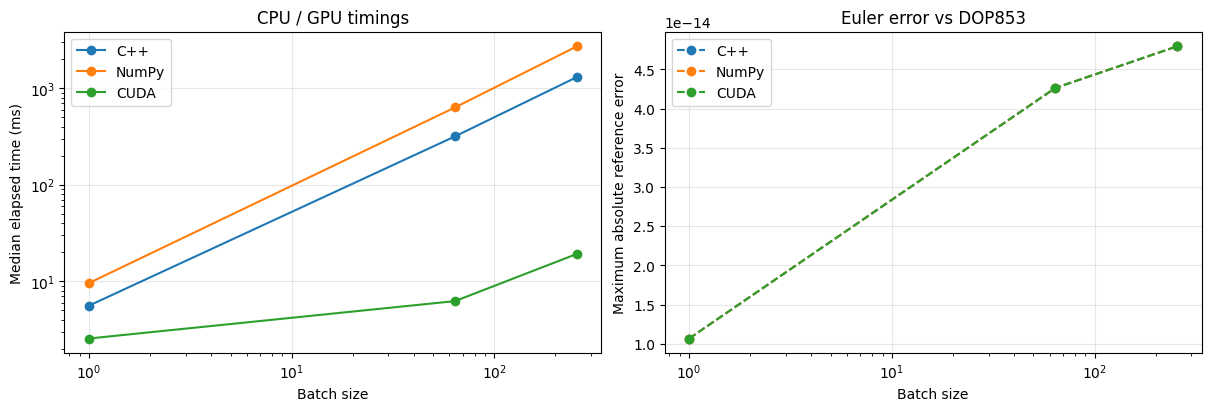

/content/CMODE/build/benchmark_20260928_091337_734360/benchmark.png

In [15]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(12, 4), constrained_layout=True)
for backend in dict.fromkeys(row["backend"] for row in rows):
    series = [row for row in rows if row["backend"] == backend]
    x = [row["batch"] for row in series]
    axes[0].plot(x, [row["median_ms"] for row in series], "o-", label=backend)
    axes[1].plot(x, [row["max_abs_error_ref"] for row in series], "o--", label=backend)
axes[0].set(xlabel="Batch size", ylabel="Median elapsed time (ms)", yscale="log", title="CPU / GPU timings")
axes[1].set(xlabel="Batch size", ylabel="Maximum absolute reference error", title="Euler error vs DOP853")
for ax in axes:
    ax.set_xscale("log")
    ax.grid(True, alpha=0.3)
    ax.legend()
fig.savefig(output / "benchmark.png", dpi=180)
plt.show()
display(FileLink(str(output / "benchmark.png")))


$ /usr/bin/python3 -m pytest tests/python -q
..................s...........                                           [100%]
29 passed, 1 skipped in 0.44s
$ /usr/bin/python3 examples/hopf_bifurcation.py --no-show --save build/hopf.png
Final time: 20.00
C++ final state [y1, y2]: [2.43009754 5.81217782]
NumPy final state [y1, y2]: [2.43009754 5.81217782]
Maximum absolute difference: 0.000e+00
Equilibrium: [2. 5.]; Hopf threshold beta = 3.5
beta = 3.6 is on the locally stable side of the threshold.
Saved figure: build/hopf.png


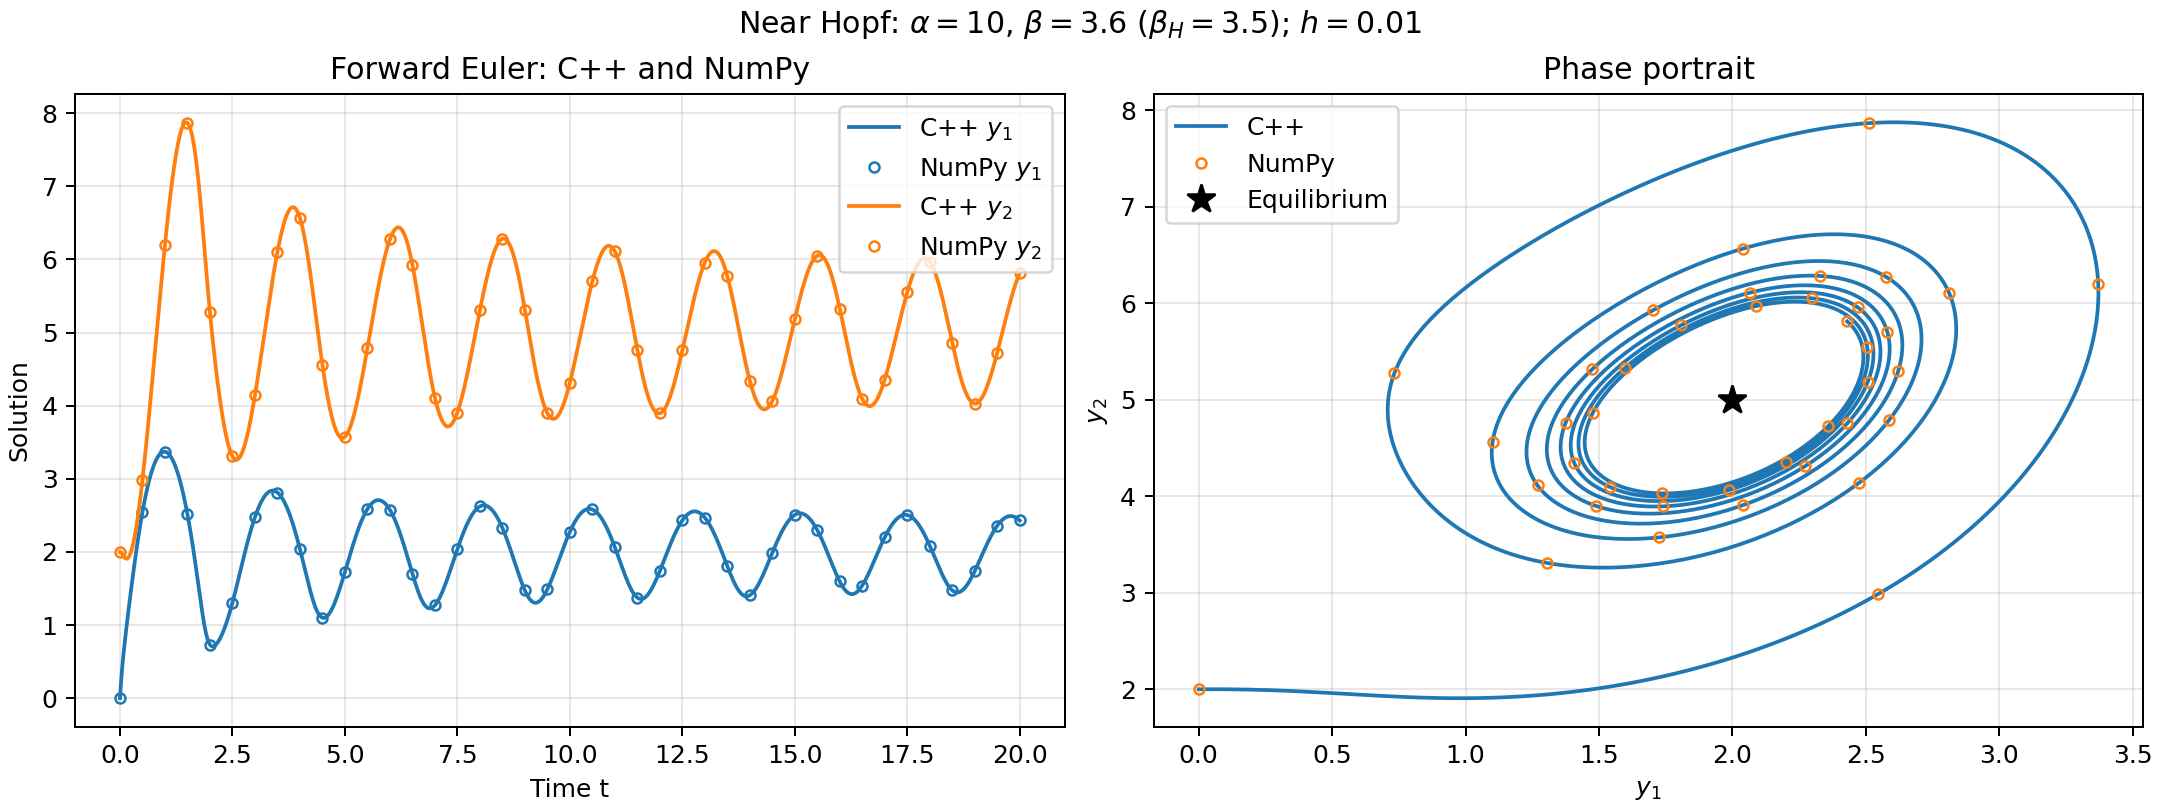

In [16]:
run_logged([sys.executable, "-m", "pytest", "tests/python", "-q"])
run_logged([sys.executable, "examples/hopf_bifurcation.py",
                "--no-show", "--save", "build/hopf.png"])
from IPython.display import Image, display
display(Image(filename="build/hopf.png"))
